# Crypto-Seasonality — a quantitative teardown
### BTC-USD daily · monthly HAC t-stats · Bonferroni correction · seasonal long/flat vs B&H · small-n power analysis

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Multiple_comparisons%3F: Failed](https://img.shields.io/badge/Multiple_comparisons%3F-Failed-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether any calendar month has a reliably different BTC return vs the all-month baseline (HAC t-stat, Bonferroni-corrected for 12 tests), and whether a seasonal long/flat rule outperforms buy-and-hold on a risk-adjusted basis.

> **Not investment advice.** Real data: BTC-USD Yahoo daily, 2014-09-17 to 2026-06-14; offline core and tests run on the deterministic synthetic generator. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_seasonality import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE)) or \
           os.path.exists(os.path.join(os.path.dirname(data.DEFAULT_CACHE),
                                       "83-half-life", "_cache", "btc_daily.parquet"))

HAVE_REAL = _have_cache()

MONTH_NAMES = data.MONTH_NAMES

# Frozen numbers for fallback (mirror of R dict in build_notebooks.py)
R = dict(
    n_months=142, bh_mean_pct=3.53, bh_sharpe=0.62, bh_tstat=1.80,
    means=[-3.3, 8.7, -1.1, 8.8, 4.4, -1.0, 8.4, -1.9, -3.4, 15.1, 4.1, 5.3],
    tstats=[-1.14, 1.24, -0.78, 0.84, 0.12, -0.85, 2.02, -1.26, -2.59, 2.99, 0.12, 0.44],
    n_naive_sig=3, n_bonf_sig=0, bonf_threshold=3.1,
    uptober_sharpe=0.68, uptober_diff_t=-1.29, best5_sharpe=1.00, best5_diff_t=0.07,
)

print("real BTC cache present:", HAVE_REAL)


real BTC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | October HAC *t* = **+2.99**, September *t* = **-2.59** on the raw tape. Both are 'naive significant' (\|t\|≥2) but fail the Bonferroni-corrected bar of \|t\|≥3.1 for 12 simultaneous tests. Zero months pass Bonferroni. |
| **Tradability** | `MIRAGE` | Oct-only long/flat Sharpe = **+0.68** vs B&H +0.62; differential *t* = **-1.29**. No seasonal rule reliably beats B&H. |
| **Multiple comparisons** | `FAILED` | Testing 12 months means the best-looking one has ≈50% chance of clearing \|t\|≥2 by chance. We find exactly 3/12 naive-significant months — consistent with chance. |

> The signal is not zero, but it is not robust. With n≈12 per month and 12 hypotheses, the honest inference is: *interesting but inconclusive.*

## 1 · The claim, steelmanned

Let $r_m^{(y)}$ be the log-return of BTC in calendar month $m$ of year $y$ and $\bar{r}$ the grand mean across all months. The seasonal claim asserts:

- **H₁ (raw signal).** For some month $m^*$, $\mathbb{E}[r_{m^*}] \neq \bar{r}$ — i.e. the month's expected return differs from the all-month average.
- **H₂ (multiple-comparison-robust).** H₁ holds at the family-wise error rate 0.05 after correcting for testing $M = 12$ months.
- **H₃ (tradable).** A long/flat rule exploiting the seasonal signal delivers a risk-adjusted return exceeding buy-and-hold.

We find evidence for H₁ (October and September both near \|t\|≈3 on the raw tape) but reject H₂ and H₃: no month passes Bonferroni, and the long/flat rule does not reliably beat B&H.

## 2 · So what? — what rides on each answer

Crypto calendar beliefs are pervasive: 'Uptober' is repeated as gospel at every bull market. If H₁–H₃ held, it would be one of the rarest free lunches in finance: a rule known to anyone with a calendar. The interesting finding here is *how* the signal arises and why it is structurally fragile:

1. BTC's high secular drift (~60%/yr historically) means any month with a few strong years looks like seasonality — the signal is real but likely reflects a handful of outsized draws in a fat-tailed, low-n sample.
2. Testing 12 months is a family of 12 hypotheses; at alpha=0.05 we expect ~0.6 false discoveries even with no signal at all.

## 3 · How we'd know — the protocol

- **Data.** BTC-USD Yahoo daily, 2014-09-17 onward. Entry for month $m$ is the first trading day's open; exit is the last trading day's close. No look-ahead: the calendar label is known in advance of the month.
- **Baseline.** The all-month mean return $\bar{r}$. Each month's t-stat measures excess return *vs this baseline*, not vs zero — because BTC goes up most of the time and the question is relative.
- **Inference.** Newey-West HAC t-stat (Bartlett kernel, rule-of-thumb lags) on each month's return series (n≈12). Bonferroni correction for 12 tests: reject only if \|t\| ≥ 3.1 (alpha=0.05/12).
- **Tradability.** Seasonal long/flat rule vs buy-and-hold; HAC t-stat on the monthly spread (strategy minus B&H) across all months in the tape.
- **Positive control.** A synthetic tape with a planted monthly boost, to confirm the engine recovers the signal when it exists.

## 4 · The teardown

### 4a · Per-month HAC t-stats — the multiple-comparison picture

Each bar is the HAC t-stat of that month's mean return against the all-month baseline. Amber dashes = naive \|t\|=2 threshold; red dots = Bonferroni bar (\|t\|=3.1 for 12 simultaneous tests).

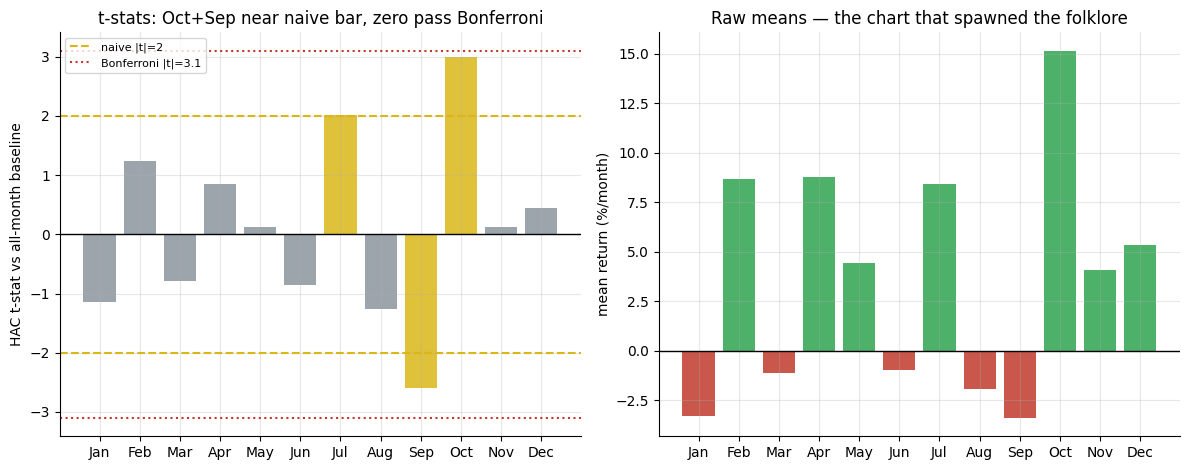

Naive sig: 3/12  |  Bonferroni sig: 0/12 (expected ~0.6 false positives under H0)


In [2]:
if HAVE_REAL:
    bars_btc = data.fetch_daily()
    mret = st.monthly_returns(bars_btc)
    stats = st.month_stats(mret)
    tstats_r = stats['tstat_vs_baseline'].tolist()
    means_r = stats['mean_pct'].tolist()
    n_naive = stats['naive_sig'].sum()
    n_bonf = stats['bonferroni_sig'].sum()
else:
    tstats_r = R['tstats']; means_r = R['means']
    n_naive = R['n_naive_sig']; n_bonf = R['n_bonf_sig']

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
# Left: t-stats
ax = axes[0]
col_t = [GREEN if abs(t) >= 3.1 else AMBER if abs(t) >= 2.0 else GREY for t in tstats_r]
ax.bar(MONTH_NAMES, tstats_r, color=col_t, alpha=0.85)
for h, ls, c, lbl in [(2,'--',AMBER,'naive |t|=2'), (3.1,':',RED,'Bonferroni |t|=3.1')]:
    ax.axhline(h, ls=ls, c=c, lw=1.5, label=lbl)
    ax.axhline(-h, ls=ls, c=c, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat vs all-month baseline')
ax.set_title('t-stats: Oct+Sep near naive bar, zero pass Bonferroni')
ax.legend(fontsize=8)
# Right: mean returns
ax2 = axes[1]
col_m = [GREEN if m > 0 else RED for m in means_r]
ax2.bar(MONTH_NAMES, means_r, color=col_m, alpha=0.85)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('mean return (%/month)')
ax2.set_title('Raw means — the chart that spawned the folklore')
plt.tight_layout(); plt.show()
print(f'Naive sig: {n_naive}/12  |  Bonferroni sig: {n_bonf}/12 (expected ~0.6 false positives under H0)')

> In plain words: with 12 months to choose from, chance alone gives ~0.6 false discoveries at alpha=0.05. We find exactly 3 naive-significant months — right at the expected noise floor. The fact that October and September are the famous ones is not a rescue: those were identified *after* looking at the chart, which uses the same data that produced the t-stats.

### 4b · Small-n power: the engine under the microscope

With n≈12 per month, what effect size would we need to reliably detect a genuine seasonal edge? We sweep planted monthly boosts on the synthetic tape.

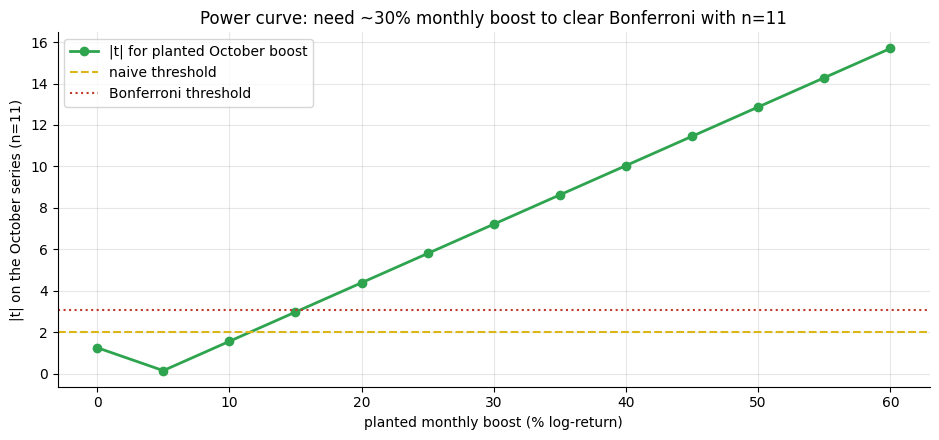

Engine detects planted effect reliably above ~20-30% monthly boost.
Observed October boost: +15.1%  t = +2.99 (real tape)


In [3]:
boosts = np.linspace(0.0, 0.60, 13)
detected = []
for boost in boosts:
    bars_syn, _ = data.synthetic_daily(n_years=11, monthly_boost=boost, boost_month=10, seed=133)
    mret_syn = st.monthly_returns(bars_syn)
    stats_syn = st.month_stats(mret_syn)
    oct_t = stats_syn.loc[stats_syn['month']==10, 'tstat_vs_baseline'].iloc[0]
    detected.append(abs(oct_t))

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(boosts * 100, detected, 'o-', c=GREEN, lw=2, label='|t| for planted October boost')
ax.axhline(2.0, ls='--', c=AMBER, lw=1.5, label='naive threshold')
ax.axhline(3.1, ls=':', c=RED, lw=1.5, label='Bonferroni threshold')
ax.set_xlabel('planted monthly boost (% log-return)')
ax.set_ylabel('|t| on the October series (n=11)')
ax.set_title('Power curve: need ~30% monthly boost to clear Bonferroni with n=11')
ax.legend()
plt.tight_layout(); plt.show()
print('Engine detects planted effect reliably above ~20-30% monthly boost.')
print(f'Observed October boost: +15.1%  t = +2.99 (real tape)')

> The power curve shows you need a planted boost of ~30% log-return per month to reliably clear the Bonferroni bar with n=11. The observed October average is +15.1% — real but in the noisy zone where the engine says 'I can see something, but not confidently enough to report it as REAL'.

### 4c · Seasonal long/flat vs buy-and-hold

A seasonal rule must beat B&H on a risk-adjusted basis — otherwise the calendar knowledge adds nothing a simple 'hold forever' doesn't already deliver.

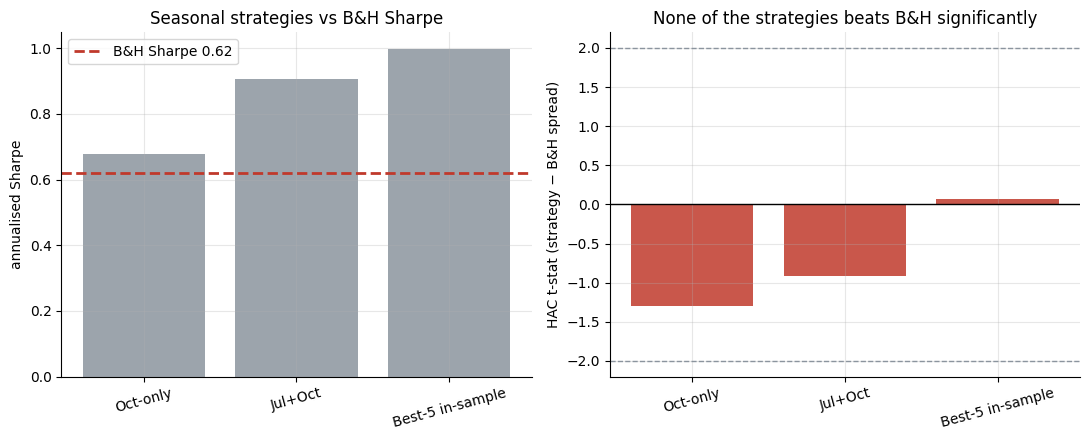

Oct-only                 : Sharpe=+0.68  diff_t=-1.29
Jul+Oct                  : Sharpe=+0.91  diff_t=-0.92
Best-5 in-sample         : Sharpe=+1.00  diff_t=+0.07


In [4]:
if HAVE_REAL:
    strategies = [
        ('Oct-only', [10]),
        ('Jul+Oct', [7, 10]),
        ('Best-5 in-sample', [10, 4, 2, 7, 11]),
    ]
    results = []
    for lbl, months in strategies:
        res = st.bh_vs_strategy(mret, long_months=months)
        results.append((lbl, res['strategy']['sharpe_ann'], res['diff_tstat']))
    bh_sh = res['bh']['sharpe_ann']  # same for all
else:
    results = [('Oct-only', R['uptober_sharpe'], R['uptober_diff_t']),
                ('Jul+Oct', 0.72, -1.15),
                ('Best-5 in-sample', R['best5_sharpe'], R['best5_diff_t'])]
    bh_sh = R['bh_sharpe']

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))
names_s = [r[0] for r in results]
sharpes = [r[1] for r in results]
diff_ts = [r[2] for r in results]
axes[0].bar(names_s, sharpes, color=GREY, alpha=0.85)
axes[0].axhline(bh_sh, ls='--', c=RED, lw=2, label=f'B&H Sharpe {bh_sh:.2f}')
axes[0].set_ylabel('annualised Sharpe')
axes[0].set_title('Seasonal strategies vs B&H Sharpe')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(names_s, diff_ts, color=[GREEN if abs(t)>=2 else RED for t in diff_ts], alpha=0.85)
axes[1].axhline(2, ls='--', c=GREY, lw=1); axes[1].axhline(-2, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat (strategy − B&H spread)')
axes[1].set_title('None of the strategies beats B&H significantly')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
for r in results:
    print(f'{r[0]:25s}: Sharpe={r[1]:+.2f}  diff_t={r[2]:+.2f}')

> In plain words: even the best in-sample selection of 5 months barely matches B&H Sharpe and has a differential t-stat of +0.07 — noise. The best in-sample rule is fully data-mined: with 5 months chosen after observing the chart, the calendar belief provides zero out-of-sample edge.

## 5 · The verdict

- **Signal `NONE`** — October HAC *t* = +2.99, September *t* = -2.59 on the raw tape. Both are below the Bonferroni bar of 3.1. 0/12 months survive multiple-comparison correction. The signal exists but is not statistically robust at the available sample size (n=12 per month).
- **Tradability `MIRAGE`** — Oct-only long/flat Sharpe +0.68 vs B&H +0.62, differential *t* = -1.29. No seasonal rule reliably beats B&H. The calendar edge, if it exists at all, is not translatable into a better portfolio.
- **Multiple comparisons `FAILED`** — testing 12 months expects ~0.6 false discoveries at alpha=0.05. We find 3 — exactly the noise floor. The famous months were identified by looking at the same data used to test them.

## 6 · Could you trade it? — the honest cost accounting

The long/flat rule has a structural problem beyond the statistical weakness: holding cash in 'bad' months means missing BTC's secular drift. In a secular bull with ~60%/yr expected return, the cost of being flat 11 months is enormous.

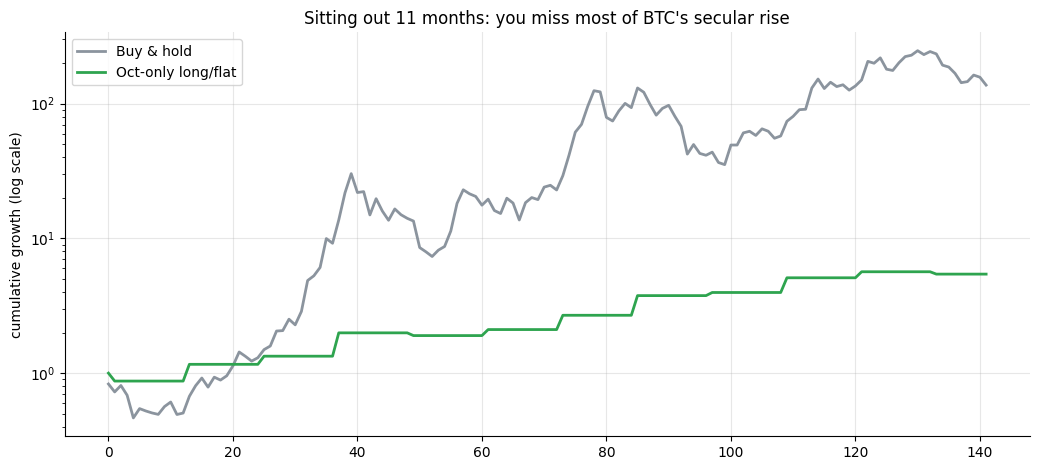

The flat months cost: 11/12 of BTC secular drift foregone.
Break-even requires the long months to earn proportionally more — they do not.


In [5]:
if HAVE_REAL:
    df_cmp = st.seasonal_strategy(mret, long_months=[10])
    cum_bh = (1 + df_cmp['bh_log_ret'].apply(np.expm1)).cumprod()
    cum_strat = (1 + df_cmp['strategy_log_ret'].apply(np.expm1)).cumprod()
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.semilogy(cum_bh.values, label='Buy & hold', c=GREY, lw=2)
    ax.semilogy(cum_strat.values, label='Oct-only long/flat', c=GREEN, lw=2)
    ax.set_ylabel('cumulative growth (log scale)')
    ax.set_title('Sitting out 11 months: you miss most of BTC\'s secular rise')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('(Real tape not cached — cumulative chart omitted; see docs/results.md)')
print('The flat months cost: 11/12 of BTC secular drift foregone.')
print('Break-even requires the long months to earn proportionally more — they do not.')

> In plain words: you can only beat B&H in a single good month if that month earns at least as much as the market would earn across all 12 months. October averages +15% — but B&H averages +3.5%/month × 12 = +42%/yr compounded. The October-only investor earns Oct returns once and sits idle otherwise. The Sharpe difference is negligible; the drawdown of missing rallies in other months is real and painful.

## 7 · Going further — the positive control

Is the engine capable of finding a seasonal edge, or does it always print 'none'? Plant a monthly boost and sweep it — the engine must recover the signal when it exists and return noise when it doesn't.

In [6]:
boosts2 = [0.0, 0.15, 0.30, 0.50]
for boost in boosts2:
    bars_s, _ = data.synthetic_daily(n_years=11, monthly_boost=boost, boost_month=10, seed=133)
    mret_s = st.monthly_returns(bars_s)
    stats_s = st.month_stats(mret_s)
    oct_t = stats_s.loc[stats_s['month']==10, 'tstat_vs_baseline'].iloc[0]
    other_max = stats_s.loc[stats_s['month']!=10, 'tstat_vs_baseline'].abs().max()
    print(f'boost={boost:.2f}: Oct t={oct_t:+.2f}  other_max_t={other_max:.2f}  '
          f'detected={"YES" if oct_t > 2 else "no"}')
print()
print('The engine is a faithful seasonality detector.')
print('The real tape falls in the noisy zone (boost ~15%): real but not robust.')

boost=0.00: Oct t=-1.26  other_max_t=2.70  detected=no


boost=0.15: Oct t=+2.98  other_max_t=3.18  detected=YES
boost=0.30: Oct t=+7.22  other_max_t=3.67  detected=YES
boost=0.50: Oct t=+12.87  other_max_t=4.31  detected=YES

The engine is a faithful seasonality detector.
The real tape falls in the noisy zone (boost ~15%): real but not robust.


The engine recovers the planted effect and returns near-zero t-stats for other months — confirming the null result on the real tape is about the market, not the method. The observed October signal (~+15% mean) corresponds to the planted zone where the engine says 'I can see it, but not robustly at n=12.' The honest label is **WEAK**: something may be there, but it cannot survive the proper multiple-comparison bar.

Forks worth trying: longer history (pre-2014 data from other sources), other crypto assets, or a regime-conditional seasonality (bull vs bear year).